# **Robustness check**

**MSc thesis Euan Bronsky**

**Notebook number: 6**

This notebook constructs an alternative estimation-evaluation approach. Specifically, the models are estimated using a rolling window of 500 observations, corresponding to approximately two years of data, after which the next 250 observations, approximately one year, are forecast out-of-sample.

----------------------

- **Import dependencies**

In [1]:
%reset -f
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sympy.abc import theta
from patsy import dmatrix
from statsmodels.tsa.api import VAR
import statsmodels.api as sm
import pickle
from patsy import build_design_matrices
from scipy.stats import norm
from matplotlib import cm
from matplotlib.colors import LinearSegmentedColormap
import statsmodels.formula.api as smf
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
import random
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from scipy.stats import norm

- **Load the data**

In [2]:
# Import data
data = pd.read_parquet("/Users/euanbronsky/Downloads/data_final_final.parquet")

# Locate the correct indices
data_select = data.loc[data.groupby(['quote_date', 'moneyness_group', 'maturity_group'])['distance'].idxmin()]

# Maintain only groups with length 24 and sort the dates
data_select = data_select.groupby('quote_date').filter(lambda x: len(x) == 24)

- **Train-test split**

In [3]:
# Extract dates
dates = np.sort(data_select['quote_date'].unique())
split = int((2 / 3) * len(dates))
train_dates = dates[:split]
test_dates = dates[split:]

# Create a train and test split and ensure fixed order
x_train = data_select[data_select['quote_date'].isin(train_dates)].copy().sort_values(['quote_date', 'moneyness_group', 'maturity_group']).reset_index(drop=True)
x_test = data_select[data_select['quote_date'].isin(test_dates)].copy().sort_values(['quote_date', 'moneyness_group', 'maturity_group']).reset_index(drop=True)

# **1. VAR model**

----------------------

This section implements the rolling-window version of the VAR benchmark. The code defines a 500-day estimation window and a 250-day out-of-sample evaluation window, then repeatedly re-estimates the VAR parameters as the window moves through time. For each rolling block, the data are split into training and testing dates, the model is estimated using the bucketed implied volatility data, and the filtered state is updated through the training sample. The resulting parameters are then used to generate full-contract out-of-sample forecasts.

- **Prepare group function**

In [4]:
# Group preparing function
def prepare_groups(x):

    # Sort values
    x = x.sort_values(['quote_date', 'moneyness_group', 'maturity_group']).reset_index(drop=True)

    # Extract dates and create empty lists
    dates = np.sort(x['quote_date'].unique())
    y_groups = []
    Z_groups = []

    # Loop over dates
    for date in dates:

        # Extract groups
        group = x[x['quote_date'] == date]

        # Extract relevant variables and append to lists
        y_groups.append(group['log_iv'].to_numpy(dtype=float))
        Z_groups.append(group[['constant', 'M', 'moneyness_squared', 'T', 'interaction']].to_numpy(dtype=float))

    # return the results
    return dates, y_groups, Z_groups

- **Kalman estimation function**

In [5]:
# Kalman estimation function
def kalman_est(par, y_groups, Z_groups):

    # Extract parameters
    c = par[:5]
    T = np.diag(np.tanh(par[5:10] / 2))
    Q = np.diag(np.exp(par[10:15]))
    sigma2 = np.exp(par[15:])

    # Extract n and p
    n_dates = len(y_groups)
    p = len(c)

    # Create empty arrays
    at_pred = np.zeros((p, n_dates))
    Pt_pred = np.zeros((n_dates, p, p))
    llik = np.zeros(n_dates)

    # Initialize using unconditional moments
    at_pred[:, 0] = np.linalg.inv(np.eye(p) - T) @ c
    Pt_pred[0, :, :] = (np.linalg.inv(np.eye(p ** 2) - np.kron(T, T)) @ Q.reshape(-1, order='F')).reshape((p, p), order='F')

    # Loop over the series
    for t in range(n_dates):

        # Extract arrays
        yt = y_groups[t]
        Zt = Z_groups[t]

        # Series length
        Nt = len(yt)

        # Measurement equation innovation covariance matrix and inverse
        Ht = np.diag(sigma2)
        Ht_inv = np.diag(1 / sigma2)

        # Auxiliary variables
        A = Zt.T @ Ht_inv @ Zt
        b = Zt.T @ Ht_inv @ yt

        # Compute inverse and collapsed variable
        A_inv = np.linalg.inv(A)
        yt_star = A_inv @ b

        # Remainder term
        et = yt - Zt @ yt_star

        # Prediction error, prediction error variance, and inverse prediction error variance
        Ht_star = A_inv
        vt = yt_star - at_pred[:, t]
        Ft = Pt_pred[t, :, :] + Ht_star

        # Prediction error variance inverse
        Ft_inv = np.linalg.inv(Ft)
        Ft_inv_vt = Ft_inv @ vt

        # Compute log-determinants
        sign_Ft, logdet_Ft = np.linalg.slogdet(Ft)
        sign_Ht, logdet_Ht = np.linalg.slogdet(Ht)
        sign_Ht_star, logdet_Ht_star = np.linalg.slogdet(Ht_star)

        # Log-likelihood contribution
        llik_star = -0.5 * len(yt_star) * np.log(2 * np.pi) - 0.5 * logdet_Ft - 0.5 * (vt.T @ Ft_inv_vt)
        llik[t] = llik_star - 0.5 * (logdet_Ht - logdet_Ht_star) - 0.5 * (et.T @ Ht_inv @ et)

        # Compute the Kalman gain, predicted state estimate, and predicted state variance
        if t < n_dates - 1:
            Kt = T @ Pt_pred[t, :, :] @ Ft_inv
            at_pred[:, t + 1] = c + T @ at_pred[:, t] + Kt @ vt
            Pt_pred[t + 1, :, :] = T @ Pt_pred[t, :, :] @ T.T + Q - Kt @ Ft @ Kt.T

    # Return the results
    return -llik.sum()

- **Minimize the likelihood**

In [6]:
# Minimize the likelihood
def minimize_llik(x):

    # Extract the groups
    dates, y_groups, Z_groups = prepare_groups(x)

    # Extract the parameters
    c_ini = [0.1] * 5
    T_ini = np.asarray([0.7] * 5)
    Q_ini = [0.003] * 5
    sigma2_ini = [0.003] * 24

    # List of initial parameter values
    par_ini = list(c_ini) + list(2 * np.arctanh(T_ini)) + list(np.log(Q_ini)) + list(np.log(sigma2_ini))

    # Set counter
    counter = {'i': 0}
    def print_iter(xk):
        counter['i'] += 1
        print("Iteration", counter['i'])

    T_max = 0.94
    raw_T_max = 2 * np.arctanh(T_max)

    bounds = (
        [(None, None)] * 5
        + [(None, raw_T_max)] * 5
        + [(None, None)] * 5
        + [(None, None)] * 24
    )

    # Minimize the function and obtain parameters and likelihood
    res = minimize(kalman_est, par_ini, bounds=bounds, args=(y_groups, Z_groups), method='L-BFGS-B', callback=print_iter, options={
        "maxiter": 2000,
        "maxfun": 100000,
        "ftol": 1e-8,
        "gtol": 1e-5,
        "maxls": 50
    })
    par = res.x
    llik = -res.fun

    # Return the results
    return par, llik, res

- **Transform the parameters**

In [7]:
# Transform the parameters
def transf_par(par):

    # Transform parameters
    c = par[:5]
    T = np.diag(np.tanh(par[5:10] / 2))
    Q = np.diag(np.exp(par[10:15]))
    sigma2 = np.exp(par[15:])

    # Return the results
    return c, T, Q, sigma2

- **Rolling window**

In [8]:
# Estimation-evaluation split
R = 500
H = 250

# Sort all available dates
all_dates = np.sort(data_select["quote_date"].unique())

# Create empty list for OOS predictions
rolling_oos_predictions = []

# Loop over rolling windows
for j, start in enumerate(range(0, len(all_dates) - R, H), start=1):

    # Print rolling block number
    print("Rolling block", j)

    # Select training and testing dates
    train_dates = all_dates[start:start + R]
    test_dates = all_dates[start + R:min(start + R + H, len(all_dates))]

    # Select bucketed training and testing data
    x_train = data_select[data_select["quote_date"].isin(train_dates)].copy()
    x_test_bucket = data_select[data_select["quote_date"].isin(test_dates)].copy()
    x_test_full = data[data["quote_date"].isin(test_dates)].copy()

    # Sort the data
    x_train = x_train.sort_values(["quote_date", "moneyness_group", "maturity_group"]).reset_index(drop=True)
    x_test_bucket = x_test_bucket.sort_values(["quote_date", "moneyness_group", "maturity_group"]).reset_index(drop=True)
    x_test_full = x_test_full.sort_values(["quote_date", "moneyness_group", "maturity_group"]).reset_index(drop=True)

    # Estimate VAR model on bucketed data
    par_raw, llik, res = minimize_llik(x_train)
    c, T, Q, sigma2 = transf_par(par_raw)

    # Prepare groups
    dates_train, y_train_groups, Z_train_groups = prepare_groups(x_train)
    dates_test_bucket, y_test_bucket_groups, Z_test_bucket_groups = prepare_groups(x_test_bucket)
    dates_test_full, y_test_full_groups, Z_test_full_groups = prepare_groups(x_test_full)

    # Number of factors
    p = len(c)

    # Initialize the predicted state and covariance
    a_pred = np.linalg.inv(np.eye(p) - T) @ c
    P_pred = (np.linalg.inv(np.eye(p ** 2) - np.kron(T, T)) @ Q.reshape(-1, order="F")).reshape((p, p), order="F")

    # Compute inverse measurement covariance
    H_inv = np.diag(1 / sigma2)

    # Filter through bucketed training data
    for t in range(len(dates_train)):

        # Extract observation vector and loading matrix
        yt = y_train_groups[t]
        Zt = Z_train_groups[t]

        # Compute relevant variables
        A = Zt.T @ H_inv @ Zt
        b = Zt.T @ H_inv @ yt
        A_inv = np.linalg.inv(A)

        # Compute innovations, its covariance, and inverse
        vt = A_inv @ b - a_pred
        Ft = P_pred + A_inv
        Ft_inv = np.linalg.inv(Ft)

        # Compute Kalman gain
        Kt = T @ P_pred @ Ft_inv

        # Compute predictions
        a_pred = c + T @ a_pred + Kt @ vt
        P_pred = T @ P_pred @ T.T + Q - Kt @ Ft @ Kt.T

    # Forecast full contracts, update with bucketed observations
    for t in range(len(dates_test_bucket)):

        # Extract testing date
        date_t = dates_test_bucket[t]

        # Extract full contract data for testing date and loading matrix
        full_t = x_test_full[x_test_full["quote_date"] == date_t].copy()
        Z_full_t = Z_test_full_groups[t]

        # Store rolling blocks, predictions, and errors
        full_t["block"] = j
        full_t["log_iv_pred_ss_var"] = Z_full_t @ a_pred
        full_t["iv_pred_ss_var"] = np.exp(full_t["log_iv_pred_ss_var"])
        full_t["forecast_error"] = full_t["iv_fun"] - full_t["iv_pred_ss_var"]
        full_t["abs_error"] = np.abs(full_t["forecast_error"])
        full_t["squared_error"] = full_t["forecast_error"] ** 2

        # Store full-contract OOS prediction
        rolling_oos_predictions.append(full_t)

        # Extract bucketed observation vector and loading matrix
        yt = y_test_bucket_groups[t]
        Zt = Z_test_bucket_groups[t]

        # Compute relevant variables
        A = Zt.T @ H_inv @ Zt
        b = Zt.T @ H_inv @ yt
        A_inv = np.linalg.inv(A)

        # Compute innovation, its covariance, and inverse
        vt = A_inv @ b - a_pred
        Ft = P_pred + A_inv
        Ft_inv = np.linalg.inv(Ft)

        # Compute Kalman gain
        Kt = T @ P_pred @ Ft_inv

        # Compute predictions
        a_pred = c + T @ a_pred + Kt @ vt
        P_pred = T @ P_pred @ T.T + Q - Kt @ Ft @ Kt.T

# Concatenate results
x_oos_ss_var_full = pd.concat(rolling_oos_predictions, ignore_index=True)

Rolling block 1
Iteration 1
Iteration 2
Iteration 3
Iteration 4
Iteration 5
Iteration 6
Iteration 7
Iteration 8
Iteration 9
Iteration 10
Iteration 11
Iteration 12
Iteration 13
Iteration 14
Iteration 15
Iteration 16
Iteration 17
Iteration 18
Iteration 19
Iteration 20
Iteration 21
Iteration 22
Iteration 23
Iteration 24
Iteration 25
Iteration 26
Iteration 27
Iteration 28
Iteration 29
Iteration 30
Iteration 31
Iteration 32
Iteration 33
Iteration 34
Iteration 35
Iteration 36
Iteration 37
Iteration 38
Iteration 39
Iteration 40
Iteration 41
Iteration 42
Iteration 43
Iteration 44
Iteration 45
Iteration 46
Iteration 47
Iteration 48
Iteration 49
Iteration 50
Iteration 51
Iteration 52
Iteration 53
Iteration 54
Iteration 55
Iteration 56
Iteration 57
Iteration 58
Iteration 59
Iteration 60
Iteration 61
Iteration 62
Iteration 63
Iteration 64
Iteration 65
Iteration 66
Iteration 67
Iteration 68
Iteration 69
Iteration 70
Iteration 71
Iteration 72
Iteration 73
Iteration 74
Iteration 75
Iteration 76
Itera

- **Compute MSE and MAE**

In [9]:
# MSE and MAE function
def mse_mae_daily(x):
    daily_errors = (x.groupby("quote_date")[["squared_error", "abs_error"]].mean().reset_index())

    # Return the results
    return pd.Series({
        "mse": daily_errors["squared_error"].mean(),
        "mae": daily_errors["abs_error"].mean()})

- **Aggregate sample**

In [10]:
# Full test sample
results_full = mse_mae_daily(x_oos_ss_var_full)

# COVID sample
x_covid = x_oos_ss_var_full[
    x_oos_ss_var_full["quote_date"].between("2020-01-01", "2022-12-31")].copy()
results_covid = mse_mae_daily(x_covid)

# Excluding 2023
x_excl_2023 = x_oos_ss_var_full[
    x_oos_ss_var_full["quote_date"].dt.year != 2023].copy()
results_excl_2023 = mse_mae_daily(x_excl_2023)

- **DOTM put region**

In [11]:
# Full sample
x_dotm_put = x_oos_ss_var_full[
    x_oos_ss_var_full["moneyness_group"] == "DOTM_put"].copy()
results_dotm_full = mse_mae_daily(x_dotm_put)

# COVID period
x_dotm_covid = x_dotm_put[
    x_dotm_put["quote_date"].between("2020-01-01", "2022-12-31")
].copy()
results_dotm_covid = mse_mae_daily(x_dotm_covid)

# Excl 2023
x_dotm_excl_2023 = x_dotm_put[
    x_dotm_put["quote_date"].dt.year != 2023].copy()
results_dotm_excl_2023 = mse_mae_daily(x_dotm_excl_2023)

- **Display results**

In [12]:
# Create DataFrame
var_results_table = pd.DataFrame({
    "full_test_sample": results_full,
    "covid_2020_2022": results_covid,
    "excl_2023": results_excl_2023,
    "dotm_put_full_test_sample": results_dotm_full,
    "dotm_put_covid_2020_2022": results_dotm_covid,
    "dotm_put_excl_2023": results_dotm_excl_2023
}).T
print(var_results_table)

                                  mse       mae
full_test_sample           207.863717  0.067457
covid_2020_2022              0.015329  0.049798
excl_2023                    0.006725  0.030599
dotm_put_full_test_sample  465.589027  0.147515
dotm_put_covid_2020_2022     0.040337  0.098533
dotm_put_excl_2023           0.017359  0.058156


# **2. OU model**

--------------------

This section implements the rolling-window version of the Ornstein-Uhlenbeck benchmark. The code first defines the functions needed to estimate the mean-reverting factor dynamics within each training window, including the discretized state-transition matrix and covariance structure. For every rolling block, the OU parameters are re-estimated on the bucketed implied volatility data, after which the filtered data is propagated forward to generate one-step-ahead full-contract forecasts.

- **Build correlation matrix**

In [13]:
# Build a valid correlation matrix
def build_R(r_params, p):

    # Build a lower-triangular matrix
    L = np.eye(p)
    idx = np.tril_indices(p, k=-1)
    L[idx] = r_params

    # Form a covariance-like matrix
    S = L @ L.T

    # Convert it into a correlation matrix
    d = np.sqrt(np.diag(S))
    R = S / np.outer(d, d)

    # Return the correlation matrix
    return R

- **Build covariance matrix**

In [14]:
# Covariance building function
def build_Q(k, gamma, R):
    p = len(k)

    # Build Q entry by entry
    Q = np.zeros((p, p))
    for i in range(p):
        for j in range(p):
            Q[i, j] = (
                R[i, j]
                * gamma[i]
                * gamma[j]
                * (1 - np.exp(-(k[i] + k[j])))
                / (k[i] + k[j])
            )

    # Return the result
    return Q

- **Kalman estimation function**

In [15]:
# Kalman estimation function
def kalman_est2(par, y_groups, Z_groups, p):

    # Extract parameters
    n_obs = len(y_groups[0])
    k = np.exp(par[:p])
    theta = par[p:2*p]
    gamma = np.exp(par[2*p:3*p])
    sigma2 = np.exp(par[3*p:3*p + n_obs])
    r_params = par[3*p + n_obs:]

    # Construct vectors and matrices
    R = build_R(r_params, p)
    Q = build_Q(k, gamma, R)
    T = np.diag(np.exp(-k))
    c = theta*(1 - np.exp(-k))

    # Extract n and p
    n_dates = len(y_groups)
    p = len(c)

    # Create empty arrays
    at_pred = np.zeros((p, n_dates))
    Pt_pred = np.zeros((n_dates, p, p))
    llik = np.zeros(n_dates)

    # Initialize using unconditional moments
    at_pred[:, 0] = np.linalg.inv(np.eye(p) - T) @ c
    Pt_pred[0, :, :] = (np.linalg.inv(np.eye(p ** 2) - np.kron(T, T)) @ Q.reshape(-1, order='F')).reshape((p, p), order='F')

    # Loop over the series
    for t in range(n_dates):

        # Extract arrays
        yt = y_groups[t]
        Zt = Z_groups[t]

        # Series length
        Nt = len(yt)

        # Measurement equation innovation covariance matrix and inverse
        Ht = np.diag(sigma2)
        Ht_inv = np.diag(1 / sigma2)

        # Auxiliary variables
        A = Zt.T @ Ht_inv @ Zt
        b = Zt.T @ Ht_inv @ yt

        # Compute inverse and collapsed variable
        A_inv = np.linalg.inv(A)
        yt_star = A_inv @ b

        # Remainder term
        et = yt - Zt @ yt_star

        # Prediction error, prediction error variance, and inverse prediction error variance
        Ht_star = A_inv
        vt = yt_star - at_pred[:, t]
        Ft = Pt_pred[t, :, :] + Ht_star

        # Prediction error variance inverse
        Ft_inv = np.linalg.inv(Ft)
        Ft_inv_vt = Ft_inv @ vt

        # Compute log-determinants
        sign_Ft, logdet_Ft = np.linalg.slogdet(Ft)
        sign_Ht, logdet_Ht = np.linalg.slogdet(Ht)
        sign_Ht_star, logdet_Ht_star = np.linalg.slogdet(Ht_star)

        # Log-likelihood contribution
        llik_star = -0.5 * len(yt_star) * np.log(2 * np.pi) - 0.5 * logdet_Ft - 0.5 * (vt.T @ Ft_inv_vt)
        llik[t] = llik_star - 0.5 * (logdet_Ht - logdet_Ht_star) - 0.5 * (et.T @ Ht_inv @ et)

        # Compute the Kalman gain, predicted state estimate, and predicted state variance
        if t < n_dates - 1:
            Kt = T @ Pt_pred[t, :, :] @ Ft_inv
            at_pred[:, t + 1] = c + T @ at_pred[:, t] + Kt @ vt
            Pt_pred[t + 1, :, :] = T @ Pt_pred[t, :, :] @ T.T + Q - Kt @ Ft @ Kt.T

    # Return the results
    return -llik.sum()

- **Minimize the likelihood**

In [16]:
# Minimize the likelihood
def minimize_llik2(x, p):

    # Extract the groups
    dates, y_groups, Z_groups = prepare_groups(x)

    # Number of observations
    n_obs = len(y_groups[0])

    # Initial parameters
    k = [0.05] * p
    theta = [0.0] * p
    gamma = [0.05] * p
    sigma2 = [0.0005] * n_obs
    r_params = [0.00] * (p * (p-1) // 2)

    # List of initial parameter values
    par_ini = list(np.log(k)) + list(theta) + list(np.log(gamma)) + list(np.log(sigma2)) + list(r_params)

    # Set counter
    counter = {'i': 0}
    def print_iter(xk):
        counter['i'] += 1
        print("Iteration", counter['i'])

    # Set bounds
    bounds = (
        [(-5, 2)] * p
        + [(-5, 5)] * p
        + [(-10, 2)] * p
        + [(np.log(1e-8), np.log(1.0))] * n_obs
        + [(-5, 5)] * (p * (p - 1) // 2))

    # Minimize the function and obtain parameters and likelihood
    res = minimize(kalman_est2, par_ini, args=(y_groups, Z_groups, p), method='L-BFGS-B', bounds=bounds,callback=print_iter, options={
        "maxiter": 2000,
        "maxfun": 100000,
        "ftol": 1e-8,
        "gtol": 1e-5,
        "maxls": 50
    })
    par = res.x
    llik = -res.fun

    # Return the results
    return par, llik, res

- **Transform the parameters**

In [17]:
# Transform the parameters
def transform_par(par, p, n_obs):

    # Transform parameters
    k = np.exp(par[:p])
    theta = par[p:2*p]
    gamma = np.exp(par[2*p:3*p])
    sigma2 = np.exp(par[3*p:3*p + n_obs])
    r_params = par[3*p + n_obs:]

    # Build covariance and correlation matrices
    R = build_R(r_params, p)
    Q = build_Q(k, gamma, R)

    # Intercept and persistence matrix
    T_diag = np.exp(-k)
    T = np.diag(T_diag)
    c = theta * (1 - T_diag)

    # Return the results
    return k, theta, gamma, sigma2, R, Q, T, c

- **Rolling window**

In [18]:
# Estimation-evaluation split
R = 500
H = 250

# Sort all available dates
all_dates = np.sort(data_select["quote_date"].unique())

# Create empty list for OOS predictions
rolling_oos_predictions_ou = []

# Loop over rolling windows
for j, start in enumerate(range(0, len(all_dates) - R, H), start=1):

    # Print rolling block number
    print("Rolling block", j)

    # Select training and testing dates
    train_dates = all_dates[start:start + R]
    test_dates = all_dates[start + R:min(start + R + H, len(all_dates))]

    # Select bucketed training and testing data
    x_train = data_select[data_select["quote_date"].isin(train_dates)].copy()
    x_test_bucket = data_select[data_select["quote_date"].isin(test_dates)].copy()
    x_test_full = data[data["quote_date"].isin(test_dates)].copy()

    # Sort the data
    x_train = x_train.sort_values(["quote_date", "moneyness_group", "maturity_group"]).reset_index(drop=True)
    x_test_bucket = x_test_bucket.sort_values(["quote_date", "moneyness_group", "maturity_group"]).reset_index(drop=True)
    x_test_full = x_test_full.sort_values(["quote_date", "moneyness_group", "maturity_group"]).reset_index(drop=True)

    # Estimate OU model on bucketed data
    par_ou_raw, llik_ou, res_ou = minimize_llik2(x_train, p=5)

    # Prepare groups
    dates_train, y_train_groups, Z_train_groups = prepare_groups(x_train)
    dates_test_bucket, y_test_bucket_groups, Z_test_bucket_groups = prepare_groups(x_test_bucket)
    dates_test_full, y_test_full_groups, Z_test_full_groups = prepare_groups(x_test_full)

    # Number of observations per bucketed date
    n_obs = len(y_train_groups[0])

    # Transform OU parameters
    k_ou, theta_ou, gamma_ou, sigma2_ou, R_ou, Q_ou, T_ou, c_ou = transform_par(
        par_ou_raw, p=5, n_obs=n_obs
    )

    # Number of factors
    p = len(c_ou)

    # Initialize the predicted state and covariance
    a_pred = np.linalg.inv(np.eye(p) - T_ou) @ c_ou
    P_pred = (np.linalg.inv(np.eye(p ** 2) - np.kron(T_ou, T_ou)) @ Q_ou.reshape(-1, order="F")).reshape((p, p), order="F")

    # Compute inverse measurement covariance
    H_inv = np.diag(1 / sigma2_ou)

    # Filter through bucketed training data
    for t in range(len(dates_train)):

        # Extract observation vector and loading matrix
        yt = y_train_groups[t]
        Zt = Z_train_groups[t]

        # Compute relevant variables
        A = Zt.T @ H_inv @ Zt
        b = Zt.T @ H_inv @ yt
        A_inv = np.linalg.inv(A)

        # Compute innovations, its covariance, and inverse
        vt = A_inv @ b - a_pred
        Ft = P_pred + A_inv
        Ft_inv = np.linalg.inv(Ft)

        # Compute Kalman gain
        Kt = T_ou @ P_pred @ Ft_inv

        # Compute predictions
        a_pred = c_ou + T_ou @ a_pred + Kt @ vt
        P_pred = T_ou @ P_pred @ T_ou.T + Q_ou - Kt @ Ft @ Kt.T

    # Forecast full contracts, update with bucketed observations
    for t in range(len(dates_test_bucket)):

        # Extract testing date
        date_t = dates_test_bucket[t]

        # Extract full contract data for testing date and loading matrix
        full_t = x_test_full[x_test_full["quote_date"] == date_t].copy()
        Z_full_t = Z_test_full_groups[t]

        # Store rolling blocks, predictions, and errors
        full_t["block"] = j
        full_t["log_iv_pred_ou"] = Z_full_t @ a_pred
        full_t["iv_pred_ou"] = np.exp(full_t["log_iv_pred_ou"])
        full_t["forecast_error"] = full_t["iv_fun"] - full_t["iv_pred_ou"]
        full_t["abs_error"] = np.abs(full_t["forecast_error"])
        full_t["squared_error"] = full_t["forecast_error"] ** 2

        # Store full-contract OOS prediction
        rolling_oos_predictions_ou.append(full_t)

        # Extract bucketed observation vector and loading matrix
        yt = y_test_bucket_groups[t]
        Zt = Z_test_bucket_groups[t]

        # Compute relevant variables
        A = Zt.T @ H_inv @ Zt
        b = Zt.T @ H_inv @ yt
        A_inv = np.linalg.inv(A)

        # Compute innovation, its covariance, and inverse
        vt = A_inv @ b - a_pred
        Ft = P_pred + A_inv
        Ft_inv = np.linalg.inv(Ft)

        # Compute Kalman gain
        Kt = T_ou @ P_pred @ Ft_inv

        # Compute predictions
        a_pred = c_ou + T_ou @ a_pred + Kt @ vt
        P_pred = T_ou @ P_pred @ T_ou.T + Q_ou - Kt @ Ft @ Kt.T

# Concatenate results
x_oos_ou_full = pd.concat(rolling_oos_predictions_ou, ignore_index=True)

Rolling block 1
Iteration 1
Iteration 2
Iteration 3
Iteration 4
Iteration 5
Iteration 6
Iteration 7
Iteration 8
Iteration 9
Iteration 10
Iteration 11
Iteration 12
Iteration 13
Iteration 14
Iteration 15
Iteration 16
Iteration 17
Iteration 18
Iteration 19
Iteration 20
Iteration 21
Iteration 22
Iteration 23
Iteration 24
Iteration 25
Iteration 26
Iteration 27
Iteration 28
Iteration 29
Iteration 30
Iteration 31
Iteration 32
Iteration 33
Iteration 34
Iteration 35
Iteration 36
Iteration 37
Iteration 38
Iteration 39
Iteration 40
Iteration 41
Iteration 42
Iteration 43
Iteration 44
Iteration 45
Iteration 46
Iteration 47
Iteration 48
Iteration 49
Iteration 50
Iteration 51
Iteration 52
Iteration 53
Iteration 54
Iteration 55
Iteration 56
Iteration 57
Iteration 58
Iteration 59
Iteration 60
Iteration 61
Iteration 62
Iteration 63
Iteration 64
Iteration 65
Iteration 66
Iteration 67
Iteration 68
Iteration 69
Iteration 70
Iteration 71
Iteration 72
Iteration 73
Iteration 74
Iteration 75
Iteration 76
Itera

- **Aggregate sample results**

In [19]:
# Full test sample
results_full = mse_mae_daily(x_oos_ou_full)

# COVID sample
x_covid = x_oos_ou_full[
    x_oos_ou_full["quote_date"].between("2020-01-01", "2022-12-31")].copy()
results_covid = mse_mae_daily(x_covid)

# Excluding 2023
x_excl_2023 = x_oos_ou_full[
    x_oos_ou_full["quote_date"].dt.year != 2023].copy()
results_excl_2023 = mse_mae_daily(x_excl_2023)

- **DOTM put sample results**

In [20]:
# Full sample
x_dotm_put = x_oos_ou_full[
    x_oos_ou_full["moneyness_group"] == "DOTM_put"].copy()
results_dotm_full = mse_mae_daily(x_dotm_put)

# COVID results
x_dotm_covid = x_dotm_put[
    x_dotm_put["quote_date"].between("2020-01-01", "2022-12-31")].copy()
results_dotm_covid = mse_mae_daily(x_dotm_covid)

# Excluding 2023
x_dotm_excl_2023 = x_dotm_put[
    x_dotm_put["quote_date"].dt.year != 2023].copy()
results_dotm_excl_2023 = mse_mae_daily(x_dotm_excl_2023)

- **Display results**

In [21]:
# Create DataFrame
ou_results_table = pd.DataFrame({
    "full_test_sample": results_full,
    "covid_2020_2022": results_covid,
    "excl_2023": results_excl_2023,
    "dotm_put_full_test_sample": results_dotm_full,
    "dotm_put_covid_2020_2022": results_dotm_covid,
    "dotm_put_excl_2023": results_dotm_excl_2023}).T
print(ou_results_table)

                                mse       mae
full_test_sample           0.281045  0.035689
covid_2020_2022            0.029452  0.055687
excl_2023                  0.010854  0.031382
dotm_put_full_test_sample  0.649019  0.071808
dotm_put_covid_2020_2022   0.076528  0.115073
dotm_put_excl_2023         0.027959  0.060938


# **3. Spline model**

--------------------

This section implements the rolling-window version of the tensor-spline OU model. The code defines the spline basis functions used to represent the cross-sectional implied volatility surface and estimates the corresponding time-varying spline coefficients within each rolling training window, and models their evolution using OU dynamics. For each rolling block, the spline prior surface is re-estimated and used to generate full-contract one-step-ahead forecasts over the next testing window.

In [22]:
# Spline function for training data
def build_train_spline_data(x):

    # Sort the values
    x = x.sort_values(["quote_date", "moneyness_group", "maturity_group"]).reset_index(drop=True)

    # Construct moneyness basis
    m_basis = dmatrix(
        "bs(M, df=3, degree=3, include_intercept=False) - 1",
        data=x,
        return_type="dataframe")

    # Construct maturity basis
    tau_basis = dmatrix(
        "bs(T, df=3, degree=3, include_intercept=False) - 1",
        data=x,
        return_type="dataframe")

    # Extract information
    m_design_info = m_basis.design_info
    tau_design_info = tau_basis.design_info

    # Construct the columns
    m_basis.columns = [f"m_basis_{j}" for j in range(m_basis.shape[1])]
    tau_basis.columns = [f"tau_basis_{j}" for j in range(tau_basis.shape[1])]

    # Construct the interaction basis
    interaction_basis = pd.concat({
        f"{m_col}_x_{tau_col}": m_basis[m_col] * tau_basis[tau_col]
        for m_col in m_basis.columns
        for tau_col in tau_basis.columns
    }, axis=1)

    # Construct the regressor matrix and the basis columns
    Z_df = pd.concat([m_basis, tau_basis, interaction_basis], axis=1)
    basis_cols = ["constant"] + Z_df.columns.tolist()

    # Construct DF of all data
    x_spline = pd.concat([x, Z_df], axis=1)

    # Return the results
    return x_spline, basis_cols, m_design_info, tau_design_info

In [23]:
# Spline testing function
def build_spline_data(x, keep_24=False):
    # Sort the data
    x = x.sort_values(
        ["quote_date", "moneyness_group", "maturity_group"]
    ).reset_index(drop=True)

    # Ensure it doesn't go outsize the range of possible values
    M_min, M_max = x_train["M"].min(), x_train["M"].max()
    dte_min, dte_max = x_train["T"].min(), x_train["T"].max()

    # Filter the data
    x_oos = x[
        (x["M"] >= M_min) &
        (x["M"] <= M_max) &
        (x["T"] >= dte_min) &
        (x["T"] <= dte_max)
        ].copy().reset_index(drop=True)

    # Construct the moneyness basis
    m_basis = build_design_matrices([m_design_info], x_oos, return_type="dataframe")[0]

    # Construct the maturity basis
    tau_basis = build_design_matrices([tau_design_info], x_oos, return_type="dataframe")[0]

    # Construct columns
    m_basis.columns = [f"m_basis_{j}" for j in range(m_basis.shape[1])]
    tau_basis.columns = [f"tau_basis_{j}" for j in range(tau_basis.shape[1])]

    # Construct interaction basis
    interaction_basis = pd.concat({
        f"{m_col}_x_{tau_col}": m_basis[m_col] * tau_basis[tau_col]
        for m_col in m_basis.columns
        for tau_col in tau_basis.columns
    }, axis=1)

    # Construct the regressor matrix and add it to data
    Z_df = pd.concat([m_basis, tau_basis, interaction_basis], axis=1)
    x_spline = pd.concat([x_oos, Z_df], axis=1)

    # Case where the bucketed data is used
    if keep_24:
        x_spline = (
            x_spline
            .groupby("quote_date")
            .filter(lambda z: len(z) == 24)
            .sort_values(['quote_date', 'moneyness_group', 'maturity_group'])
            .reset_index(drop=True))
        x_spline = x_spline[x_train_spline.columns]

    # Return the results
    return x_spline, basis_cols, m_design_info, tau_design_info

- **Apply functions**

In [24]:
# Apply the training function
x_train_spline, basis_cols, m_design_info, tau_design_info = build_train_spline_data(x_train)

# Apply the testing function
x_test_spline, basis_cols, m_design_info, tau_design_info = build_spline_data(x_test, keep_24=True)

# Extract the full data including spline basis
data_spline_full, basis_cols, m_design_info, tau_design_info = build_spline_data(data, keep_24=False)

# Construct the full matrix
x_full_spline = (
    pd.concat([x_train_spline, x_test_spline], axis=0)
    .sort_values(['quote_date', 'moneyness_group', 'maturity_group'])
    .reset_index(drop=True))

- **Prepare group function**

In [25]:
# Group preparing function
def prepare_groups_spline(x):
    # Sort values
    x = x.sort_values(['quote_date', 'moneyness_group', 'maturity_group']).reset_index(drop=True)

    # Sort the dates
    dates = np.sort(x['quote_date'].unique())

    # Create empty lists
    y_groups = []
    Z_groups = []

    # Loop over the dates
    for date in dates:
        # Extract the groups
        group = x[x['quote_date'] == date]

        # Append the y and Z groups to the lists
        y_groups.append(group['log_iv'].to_numpy(dtype=float))
        Z_groups.append(group[basis_cols].to_numpy(dtype=float))

    # Return the results
    return dates, y_groups, Z_groups

- **Kalman estimation function**

In [26]:
# Collapsed Kalman estimation function
def kalman_estimation_spline(par, y_groups, Z_groups):

    # Dimension of the state vector
    p = Z_groups[0].shape[1]

    # Specify the dates and number of unique dates
    n_dates = len(y_groups)
    n_obs = len(y_groups[0])

    # Parameters
    k = np.exp(par[:p])
    theta = par[p:2 * p]
    c = theta * (1 - np.exp(-k))
    sigma2 = np.exp(par[2 * p:2 * p + n_obs])

    # Covariance matrix
    gamma = np.exp(par[2 * p + n_obs:3 * p + n_obs])
    r_params = par[3 * p + n_obs:]
    R = build_R(r_params, p=p)
    Q = build_Q(k, gamma, R)

    # Constant transition matrix
    T = np.diag(np.exp(-k))

    # Specify the initial values
    at_init = np.linalg.inv(np.eye(p) - T) @ c
    Pt_init = (np.linalg.inv(np.eye(p ** 2) - np.kron(T, T)) @ Q.reshape(-1, order='F')).reshape((p, p), order='F')

    # Create empty arrays
    at_pred = np.zeros((p, n_dates))
    Pt_pred = np.zeros((n_dates, p, p))
    ll = np.zeros(n_dates)

    # Store the initial values
    at_pred[:, 0] = at_init
    Pt_pred[0, :, :] = Pt_init

    # Loop over the dates
    for t in range(n_dates):

        # Extract the groups
        yt = y_groups[t]
        Zt = Z_groups[t]

        # Covariance matrix of the measurement equation innovation
        Nt = len(yt)
        Ht = np.diag(sigma2)
        Ht_inv = np.diag(1 / sigma2)

        A = Zt.T @ Ht_inv @ Zt
        b = Zt.T @ Ht_inv @ yt

        yt_star = np.linalg.solve(A, b)

        A_inv = np.linalg.solve(A, np.eye(p))

        # Remainder term
        et = yt - Zt @ yt_star

        # Prediction error, prediction error variance, and inverse prediction error variance
        Ht_star = A_inv
        vt = yt_star - at_pred[:, t]
        Ft = Pt_pred[t, :, :] + Ht_star
        Ft_inv_vt = np.linalg.solve(Ft, vt)
        Ft_inv = np.linalg.solve(Ft, np.eye(p))

        # Compute log determinants
        sign_Ft, logdet_Ft = np.linalg.slogdet(Ft)
        logdet_Ht = np.sum(np.log(sigma2))
        sign_Ht_star, logdet_Ht_star = np.linalg.slogdet(Ht_star)

        # Log-likelihood contribution
        llik_star = -0.5 * len(yt_star) * np.log(2 * np.pi) - 0.5 * logdet_Ft - 0.5 * (vt.T @ Ft_inv_vt)
        ll[t] = llik_star - 0.5 * (logdet_Ht - logdet_Ht_star) - 0.5 * (et.T @ Ht_inv @ et)

        # Compute the Kalman gain, predicted state estimate, and predicted state variance
        if t < n_dates - 1:
            Kt = T @ Pt_pred[t, :, :] @ Ft_inv
            at_pred[:, t + 1] = c + T @ at_pred[:, t] + Kt @ vt
            Pt_pred[t + 1, :, :] = T @ Pt_pred[t, :, :] @ T.T + Q - Kt @ Ft @ Kt.T

    # Return the results
    return -ll.sum()

- **Minimize the log likelihood function**

In [27]:
# Minimize the log-likelihood function
def minimize_llik_spline(x):

    # Prepare the groups
    dates, y_groups, Z_groups = prepare_groups_spline(x)

    # Length of state vector and number of observations
    p = Z_groups[0].shape[1]
    n_obs = len(y_groups[0])

    # Specify initial parameters
    k_ini = [0.1] * p
    theta_ini = [0.2] * p
    sigma2_ini = [0.0007] * n_obs
    gamma_ini = [0.1] * p
    rho_ini = [0.00] * (p * (p - 1) // 2)

    # Create list of initial parameters
    par_ini = (
            list(np.log(k_ini))
            + theta_ini
            + list(np.log(sigma2_ini))
            + list(np.log(gamma_ini))
            + rho_ini)

    # Define bounds
    bounds = (
            [(np.log(1e-3), np.log(10))] * p
            + [(-5, 5)] * p
            + [(np.log(1e-8), np.log(1))] * n_obs
            + [(np.log(1e-8), np.log(10))] * p
            + [(-5, 5)] * (p * (p - 1) // 2))

    # Set iteration counter
    counter = {'i': 0}

    def print_iter(xk):
        counter['i'] += 1
        print("Iteration", counter['i'])

    # Minimize the function and obtain parameters and likelihood
    res = minimize(kalman_estimation_spline, par_ini, args=(y_groups, Z_groups), method='L-BFGS-B', callback=print_iter,
                   bounds=bounds, options={
            "maxiter": 2000,
            "maxfun": 100000,
            "ftol": 1e-8,
            "gtol": 1e-5,
            "maxls": 50
        })
    par = res.x
    llik = -res.fun

    # Return the results
    return par, llik, res

- **Transform the parameters**

In [28]:
# Transform the parameters
def transform_params_spline(par, p, n_obs):

    # Mean-reversion params
    k = np.exp(par[:p])

    # Mean params
    theta = par[p:2 * p]

    # Variance params
    sigma_2 = np.exp(par[2 * p:2 * p + n_obs])

    # Covariance and correlation matrices
    gamma = np.exp(par[2 * p + n_obs:3 * p + n_obs])
    r_params = par[3 * p + n_obs:]
    R = build_R(r_params, p=p)
    Q = build_Q(k, gamma, R)

    # Persistence parameter and intercept
    T_diag = np.exp(-k)
    T = np.diag(T_diag)
    c = theta * (1 - T_diag)

    # Return the results
    return k, theta, sigma_2, gamma, R, Q, T, c

- **Rolling estimation**

In [29]:
# Estimation-evaluation split
R = 500
H = 250

# Sort all available dates
all_dates = np.sort(data_select["quote_date"].unique())

# Create empty lists for predictions
rolling_oos_predictions_spline = []
rolling_nn_prior_predictions = []

# Function to build spline data using the training spline basis
def build_spline_data_from_train(x, x_train, basis_cols, m_design_info, tau_design_info, keep_24=False):

    # Sort data
    x = x.sort_values(["quote_date", "moneyness_group", "maturity_group"]).reset_index(drop=True)

    # Get training support
    M_min, M_max = x_train["M"].min(), x_train["M"].max()
    T_min, T_max = x_train["T"].min(), x_train["T"].max()

    # Keep only observations inside training support
    x_oos = x[
        (x["M"] >= M_min) &
        (x["M"] <= M_max) &
        (x["T"] >= T_min) &
        (x["T"] <= T_max)
    ].copy().reset_index(drop=True)

    # Build spline basis using training design information
    m_basis = build_design_matrices([m_design_info], x_oos, return_type="dataframe")[0]
    tau_basis = build_design_matrices([tau_design_info], x_oos, return_type="dataframe")[0]

    # Rename basis columns
    m_basis.columns = [f"m_basis_{j}" for j in range(m_basis.shape[1])]
    tau_basis.columns = [f"tau_basis_{j}" for j in range(tau_basis.shape[1])]

    # Build interaction basis
    interaction_basis = pd.concat({
        f"{m_col}_x_{tau_col}": m_basis[m_col] * tau_basis[tau_col]
        for m_col in m_basis.columns
        for tau_col in tau_basis.columns
    }, axis=1)

    # Combine original data and spline basis
    Z_df = pd.concat([m_basis, tau_basis, interaction_basis], axis=1)
    x_spline = pd.concat([x_oos, Z_df], axis=1)

    # Keep only dates with 24 bucketed observations if needed
    if keep_24:
        x_spline = (
            x_spline
            .groupby("quote_date")
            .filter(lambda z: len(z) == 24)
            .sort_values(["quote_date", "moneyness_group", "maturity_group"])
            .reset_index(drop=True)
        )

    return x_spline

- **Prepare group function**

In [30]:
# Function to prepare grouped spline data
def prepare_groups_spline_local(x, basis_cols):

    # Sort data
    x = x.sort_values(["quote_date", "moneyness_group", "maturity_group"]).reset_index(drop=True)

    # Extract dates
    dates = np.sort(x["quote_date"].unique())

    # Create empty lists
    y_groups = []
    Z_groups = []

    # Loop over dates
    for date in dates:

        # Select one date
        group = x[x["quote_date"] == date]

        # Store observation vector and loading matrix
        y_groups.append(group["log_iv"].to_numpy(dtype=float))
        Z_groups.append(group[basis_cols].to_numpy(dtype=float))

    # Return the results
    return dates, y_groups, Z_groups

- **Rolling window**

In [31]:
# Loop over rolling windows
for j, start in enumerate(range(0, len(all_dates) - R, H), start=1):

    # Print rolling block number
    print("Rolling block", j)

    # Select training and testing dates
    train_dates = all_dates[start:start + R]
    test_dates = all_dates[start + R:min(start + R + H, len(all_dates))]

    # Select bucketed training, bucketed testing, full testing, and full training data
    x_train = data_select[data_select["quote_date"].isin(train_dates)].copy()
    x_test_bucket = data_select[data_select["quote_date"].isin(test_dates)].copy()
    x_test_full = data[data["quote_date"].isin(test_dates)].copy()
    x_train_full = data[data["quote_date"].isin(train_dates)].copy()

    # Sort the data
    x_train = x_train.sort_values(["quote_date", "moneyness_group", "maturity_group"]).reset_index(drop=True)
    x_test_bucket = x_test_bucket.sort_values(["quote_date", "moneyness_group", "maturity_group"]).reset_index(drop=True)
    x_test_full = x_test_full.sort_values(["quote_date", "moneyness_group", "maturity_group"]).reset_index(drop=True)
    x_train_full = x_train_full.sort_values(["quote_date", "moneyness_group", "maturity_group"]).reset_index(drop=True)

    # Build spline basis on bucketed training data
    x_train_spline, basis_cols, m_design_info, tau_design_info = build_train_spline_data(x_train)

    # Build spline basis for bucketed OOS update data
    x_test_bucket_spline = build_spline_data_from_train(
        x_test_bucket, x_train, basis_cols, m_design_info, tau_design_info, keep_24=True)

    # Build spline basis for full-contract OOS evaluation data
    x_test_full_spline = build_spline_data_from_train(
        x_test_full, x_train, basis_cols, m_design_info, tau_design_info, keep_24=False)

    # Build spline basis for full-contract training prior data
    x_train_full_spline = build_spline_data_from_train(
        x_train_full, x_train, basis_cols, m_design_info, tau_design_info, keep_24=False)

    # Estimate spline model on bucketed data
    par_raw, llik_spline, res_spline = minimize_llik_spline(x_train_spline)

    # Prepare groups
    dates_train, y_train_groups, Z_train_groups = prepare_groups_spline_local(x_train_spline, basis_cols)
    dates_test_bucket, y_test_bucket_groups, Z_test_bucket_groups = prepare_groups_spline_local(x_test_bucket_spline, basis_cols)
    dates_train_full, y_train_full_groups, Z_train_full_groups = prepare_groups_spline_local(x_train_full_spline, basis_cols)
    dates_test_full, y_test_full_groups, Z_test_full_groups = prepare_groups_spline_local(x_test_full_spline, basis_cols)

    # Number of factors and observations
    p = len(basis_cols)
    n_obs = len(y_train_groups[0])

    # Transform spline parameters
    k_spline, theta_spline, sigma2_spline, gamma_spline, R_spline, Q_spline, T_spline, c_spline = transform_params_spline(
        par_raw, p=p, n_obs=n_obs)

    # Create date-position dictionaries
    train_full_pos = {d: i for i, d in enumerate(dates_train_full)}
    test_full_pos = {d: i for i, d in enumerate(dates_test_full)}

    # Initialize the predicted state and covariance
    a_pred = np.linalg.inv(np.eye(p) - T_spline) @ c_spline
    P_pred = (np.linalg.inv(np.eye(p ** 2) - np.kron(T_spline, T_spline)) @ Q_spline.reshape(-1, order="F")).reshape((p, p), order="F")

    # Compute inverse measurement covariance
    H_inv = np.diag(1 / sigma2_spline)

    # Filter through bucketed training data and store full-contract training priors
    for t in range(len(dates_train)):

        # Extract training date
        date_t = dates_train[t]

        # Store full-contract training prior if the date exists after support filtering
        if date_t in train_full_pos:

            # Extract full-contract training data for this date and loading matrix
            full_t = x_train_full_spline[x_train_full_spline["quote_date"] == date_t].copy()
            Z_full_t = Z_train_full_groups[train_full_pos[date_t]]

            # Store rolling blocks and prior predictions
            full_t["block"] = j
            full_t["log_iv_pred_spline"] = Z_full_t @ a_pred
            full_t["iv_pred_spline"] = np.exp(full_t["log_iv_pred_spline"])

            # Store full-contract training prior
            rolling_nn_prior_predictions.append(full_t)

        # Extract bucketed observation vector and loading matrix
        yt = y_train_groups[t]
        Zt = Z_train_groups[t]

        # Compute relevant variables
        A = Zt.T @ H_inv @ Zt
        b = Zt.T @ H_inv @ yt
        A_inv = np.linalg.inv(A)

        # Compute innovation, its covariance, and inverse
        vt = A_inv @ b - a_pred
        Ft = P_pred + A_inv
        Ft_inv = np.linalg.inv(Ft)

        # Compute Kalman gain
        Kt = T_spline @ P_pred @ Ft_inv

        # Compute predictions
        a_pred = c_spline + T_spline @ a_pred + Kt @ vt
        P_pred = T_spline @ P_pred @ T_spline.T + Q_spline - Kt @ Ft @ Kt.T

    # Forecast full contracts, update with bucketed OOS observations
    for t in range(len(dates_test_bucket)):

        # Extract testing date
        date_t = dates_test_bucket[t]

        # Store full-contract OOS prediction if the date exists after support filtering
        if date_t in test_full_pos:

            # Extract full-contract testing data for this date and loading matrix
            full_t = x_test_full_spline[x_test_full_spline["quote_date"] == date_t].copy()
            Z_full_t = Z_test_full_groups[test_full_pos[date_t]]

            # Store rolling blocks, predictions, and errors
            full_t["block"] = j
            full_t["log_iv_pred_spline"] = Z_full_t @ a_pred
            full_t["iv_pred_spline"] = np.exp(full_t["log_iv_pred_spline"])
            full_t["forecast_error"] = full_t["iv_fun"] - full_t["iv_pred_spline"]
            full_t["abs_error"] = np.abs(full_t["forecast_error"])
            full_t["squared_error"] = full_t["forecast_error"] ** 2

            # Store full-contract OOS prediction
            rolling_oos_predictions_spline.append(full_t)

        # Extract bucketed observation vector and loading matrix
        yt = y_test_bucket_groups[t]
        Zt = Z_test_bucket_groups[t]

        # Compute relevant variables
        A = Zt.T @ H_inv @ Zt
        b = Zt.T @ H_inv @ yt
        A_inv = np.linalg.inv(A)

        # Compute innovation, its covariance, and inverse
        vt = A_inv @ b - a_pred
        Ft = P_pred + A_inv
        Ft_inv = np.linalg.inv(Ft)

        # Compute Kalman gain
        Kt = T_spline @ P_pred @ Ft_inv

        # Compute predictions
        a_pred = c_spline + T_spline @ a_pred + Kt @ vt
        P_pred = T_spline @ P_pred @ T_spline.T + Q_spline - Kt @ Ft @ Kt.T

# Concatenate results
x_oos_spline_full = pd.concat(rolling_oos_predictions_spline, ignore_index=True)
x_nn_prior_train_full = pd.concat(rolling_nn_prior_predictions, ignore_index=True)

Rolling block 1
Iteration 1
Iteration 2
Iteration 3
Iteration 4
Iteration 5
Iteration 6
Iteration 7
Iteration 8
Iteration 9
Iteration 10
Iteration 11
Iteration 12
Iteration 13
Iteration 14
Iteration 15
Iteration 16
Iteration 17
Iteration 18
Iteration 19
Iteration 20
Iteration 21
Iteration 22
Iteration 23
Iteration 24
Iteration 25
Iteration 26
Iteration 27
Iteration 28
Iteration 29
Iteration 30
Iteration 31
Iteration 32
Iteration 33
Iteration 34
Iteration 35
Iteration 36
Iteration 37
Iteration 38
Iteration 39
Iteration 40
Iteration 41
Iteration 42
Iteration 43
Iteration 44
Iteration 45
Iteration 46
Iteration 47
Iteration 48
Iteration 49
Iteration 50
Iteration 51
Iteration 52
Iteration 53
Iteration 54
Iteration 55
Iteration 56
Iteration 57
Iteration 58
Iteration 59
Iteration 60
Iteration 61
Iteration 62
Iteration 63
Iteration 64
Iteration 65
Iteration 66
Iteration 67
Iteration 68
Iteration 69
Iteration 70
Iteration 71
Iteration 72
Iteration 73
Iteration 74
Iteration 75
Rolling block 2
It

- **Aggregate sample results**

In [32]:
# Full test sample
results_full = mse_mae_daily(x_oos_spline_full)

# COVID sample
x_covid = x_oos_spline_full[x_oos_spline_full["quote_date"].between("2020-01-01", "2022-12-31")].copy()
results_covid = mse_mae_daily(x_covid)

# Excluding 2023
x_excl_2023 = x_oos_spline_full[x_oos_spline_full["quote_date"].dt.year != 2023].copy()
results_excl_2023 = mse_mae_daily(x_excl_2023)

- **Region-specific results**

In [33]:
# Full sample
x_dotm_put = x_oos_spline_full[x_oos_spline_full["moneyness_group"] == "DOTM_put"].copy()
results_dotm_full = mse_mae_daily(x_dotm_put)

# COVID sample
x_dotm_covid = x_dotm_put[x_dotm_put["quote_date"].between("2020-01-01", "2022-12-31")].copy()
results_dotm_covid = mse_mae_daily(x_dotm_covid)

# Excluding 2023
x_dotm_excl_2023 = x_dotm_put[x_dotm_put["quote_date"].dt.year != 2023].copy()
results_dotm_excl_2023 = mse_mae_daily(x_dotm_excl_2023)

- **Display results**

In [34]:
# Create DataFrame
spline_results_table = pd.DataFrame({
    "full_test_sample": results_full,
    "covid_2020_2022": results_covid,
    "excl_2023": results_excl_2023,
    "dotm_put_full_test_sample": results_dotm_full,
    "dotm_put_covid_2020_2022": results_dotm_covid,
    "dotm_put_excl_2023": results_dotm_excl_2023
}).T
print(spline_results_table)

                                mse       mae
full_test_sample           0.004867  0.027194
covid_2020_2022            0.008476  0.034129
excl_2023                  0.005020  0.027760
dotm_put_full_test_sample  0.013742  0.063183
dotm_put_covid_2020_2022   0.025297  0.084007
dotm_put_excl_2023         0.014103  0.064069


# **4. Smoother model**

--------------------------

This section implements the rolling-window version of the neural smoother. The code uses the rolling tensor-spline OU forecasts as the prior surface and then trains the neural network residual correction within each rolling training window. For every block, the smoother learns contract-level nonlinear corrections from moneyness, maturity, and prior implied volatility, after which the trained network is applied to the next out-of-sample test window.

In [35]:
# Define neural network class
class ResidualNN(nn.Module):

    # Setup function
    def __init__(self, n_features):

        # Initialize nn.Module class
        super().__init__()

        # Create hidden layers of the neural network
        self.hidden = nn.Sequential(

            # Hidden layer 1
            nn.Linear(n_features, 80),
            nn.Tanh(),

            # Hidden layer 2
            nn.Linear(80, 80),
            nn.Tanh(),

            # Hidden layer 3
            nn.Linear(80, 80),
            nn.Tanh())

        # Linear output layer
        self.output = nn.Linear(80, 1)

        # Call the custom weight initialization function
        self.initialize_weights()

    # Weight initialization function
    def initialize_weights(self):

        # Loop over all parts of the model
        for layer in self.modules():

            # Apply initialization to linear layers
            if isinstance(layer, nn.Linear):

                # Get number of inputs and outputs of the layer
                fan_in = layer.weight.shape[1]
                fan_out = layer.weight.shape[0]

                # Standard deviation for random initialization
                std = (fan_in + fan_out) ** (-0.5)

                # Initialize weights and biases randomly
                nn.init.normal_(layer.weight, mean=0.0, std=std)
                nn.init.normal_(layer.bias, mean=0.0, std=std)

        # Set the final layers weights and bias to zero
        nn.init.zeros_(self.output.weight)
        nn.init.zeros_(self.output.bias)

    # Define what happens when data is passed through the model
    def forward(self, x):

        # Pass input features through three hidden layers
        x = self.hidden(x)

        # Pass hidden output through final layer to get one number
        log_omega_multiplier = self.output(x)

        # Exponentiate the output
        omega_multiplier = torch.exp(log_omega_multiplier)

        # return the result
        return omega_multiplier

- **Rolling window**

In [36]:
# Estimation-evaluation split for neural smoother model
R = 500
H = 250

# Extract all available quote dates
all_dates = np.sort(data_select["quote_date"].unique())

# Create empty list
rolling_oos_predictions_nn = []

# Loop over rolling windows
for j, start in enumerate(range(0, len(all_dates) - R, H), start=1):

    # Print current block
    print("Rolling NN block", j)

    # Training and testing dates
    train_dates = all_dates[start:start + R]
    test_dates = all_dates[start + R:min(start + R + H, len(all_dates))]

    # Select neural network training data
    x_train_nn = x_nn_prior_train_full[(x_nn_prior_train_full["block"] == j) & (x_nn_prior_train_full["quote_date"].isin(train_dates))].copy()

    # Select testing data
    x_test_nn = x_oos_spline_full[(x_oos_spline_full["block"] == j) & (x_oos_spline_full["quote_date"].isin(test_dates))].copy()

    # Sort values
    x_train_nn = x_train_nn.sort_values(["quote_date", "moneyness_group", "maturity_group"]).reset_index(drop=True)
    x_test_nn = x_test_nn.sort_values(["quote_date", "moneyness_group", "maturity_group"]).reset_index(drop=True)

    # Set the prior floor
    iv_prior_floor = 0.02

    # Floor the training and testing priors
    x_train_nn["iv_prior_safe"] = x_train_nn["iv_pred_spline"].clip(lower=iv_prior_floor)
    x_test_nn["iv_prior_safe"] = x_test_nn["iv_pred_spline"].clip(lower=iv_prior_floor)

    # Drop missing values
    x_train_nn = x_train_nn.dropna(subset=["M", "T", "iv_fun", "iv_pred_spline", "iv_prior_safe", "moneyness_group", "maturity_group"]).copy()
    x_test_nn = x_test_nn.dropna(subset=["M", "T", "iv_fun", "iv_pred_spline", "iv_prior_safe", "moneyness_group", "maturity_group"]).copy()

    # Define input features
    feature_cols = ["M", "T", "iv_prior_safe"]

    # Set seed
    seed = 123
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    # Extract training input features
    X = x_train_nn[feature_cols].to_numpy(dtype=float)
    y = x_train_nn[["iv_fun"]].to_numpy(dtype=float)
    iv_prior = x_train_nn[["iv_prior_safe"]].to_numpy(dtype=float)
    T_train = x_train_nn[["T"]].to_numpy(dtype=float)

    # initialize scaler
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Convert to Torch tensors
    X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.float32)
    iv_prior_tensor = torch.tensor(iv_prior, dtype=torch.float32)
    T_tensor = torch.tensor(T_train, dtype=torch.float32)

    # Build the dataset
    dataset = TensorDataset(X_tensor, y_tensor, iv_prior_tensor, T_tensor)

    # Create generator
    generator = torch.Generator().manual_seed(seed)
    loader = DataLoader(dataset, batch_size=65536, shuffle=True, generator=generator)

    # Initialize neural network
    model = ResidualNN(n_features=len(feature_cols))

    # Set initial learning rate
    current_lr = 0.001

    # Define Adam optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=current_lr,weight_decay=1e-6)

    # Set specifics
    max_epochs = 400
    lr_check_window = 100
    stop_check_window = 200
    required_improvement = 0.003

    # Create empty list
    loss_history = []

    # Loop over training epochs
    for epoch in range(max_epochs):

        # Initialize total loss
        total_loss = 0.0

        # Loop over mini-batches
        for X_batch, y_batch, iv_prior_batch, T_batch in loader:

            # Reset gradients
            optimizer.zero_grad()

            # Compute multiplier
            omega_multiplier = model(X_batch)

            # Convert to total variance and apply correction
            omega_prior = iv_prior_batch ** 2 * T_batch
            omega_pred = omega_multiplier * omega_prior

            # Convert total variance back to IV
            iv_pred = torch.sqrt(torch.clamp(omega_pred / torch.clamp(T_batch, min=1e-8), min=1e-12))

            # Compute RMSE and MAPE
            rmse = torch.sqrt(torch.mean((y_batch - iv_pred) ** 2))
            mape = torch.mean(torch.abs(y_batch - iv_pred) / torch.clamp(y_batch, min=1e-8))

            # Compute loss
            loss = rmse + mape

            # Backpropagate loss
            loss.backward()
            optimizer.step()

            # Add current loss to total
            total_loss += loss.item()

        # Compute average loss
        avg_loss = total_loss / len(loader)
        loss_history.append(avg_loss)

        # Print progress
        if epoch % 50 == 0:
            print(epoch, avg_loss, "lr:", current_lr)

        # Check whether learning rate should be reduced
        if epoch > 0 and epoch % lr_check_window == 0:

            # Get the loss from previous learning-rate check window
            old_loss = loss_history[epoch - lr_check_window]
            improvement = (old_loss - avg_loss) / old_loss

            # Reduce learning rate if improvement is too small
            if improvement < required_improvement:

                # Halve current learning rate
                current_lr = current_lr / 2

                # Update optimizer learning rate
                for param_group in optimizer.param_groups:
                    param_group["lr"] = current_lr

                # Print learning rate reduction
                print("Reduced learning rate to", current_lr, "at epoch", epoch)

        # Check whether early stopping should be applied
        if epoch > 0 and epoch % stop_check_window == 0:

            # Get loss from previous stopping window
            old_loss = loss_history[epoch - stop_check_window]
            improvement = (old_loss - avg_loss) / old_loss

            # Stop training if improvement is too small
            if improvement < required_improvement:
                print("Stopping: loss did not improve enough")
                break

    # Extract input features
    X_test = x_test_nn[feature_cols].to_numpy(dtype=float)
    X_test_scaled = scaler.transform(X_test)
    X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

    # Switch to evaluation mode
    model.eval()

    # Disable gradient tracking
    with torch.no_grad():

        # Store neural network total variance multiplier prediction
        x_test_nn["omega_multiplier_nn"] = model(X_test_tensor).numpy().flatten()

    # Compute prior total variance on test sample
    omega_prior_test = (x_test_nn["iv_prior_safe"].to_numpy(dtype=float) ** 2
        * x_test_nn["T"].to_numpy(dtype=float))

    # Apply neural network multiplier to obtain testing total variance
    omega_nn_test = (x_test_nn["omega_multiplier_nn"].to_numpy(dtype=float)
        * omega_prior_test)

    # Convert testing total variance back to IV
    x_test_nn["iv_nn"] = np.sqrt(np.maximum(omega_nn_test / np.maximum(x_test_nn["T"].to_numpy(dtype=float), 1e-8), 1e-12))

    # Store rolling block number and compute errors
    x_test_nn["block"] = j
    x_test_nn["forecast_error"] = x_test_nn["iv_fun"] - x_test_nn["iv_nn"]
    x_test_nn["abs_error"] = np.abs(x_test_nn["forecast_error"])
    x_test_nn["squared_error"] = x_test_nn["forecast_error"] ** 2

    # Append results
    rolling_oos_predictions_nn.append(x_test_nn)

# Combine all predictions into one DataFrame
x_oos_nn_full = pd.concat(rolling_oos_predictions_nn, ignore_index=True)

Rolling NN block 1
0 0.11866363137960434 lr: 0.001
50 0.0641764576236407 lr: 0.001
100 0.06019708762566248 lr: 0.001
150 0.05490471546848615 lr: 0.001
200 0.055243831127882004 lr: 0.001
250 0.05431268860896429 lr: 0.001
300 0.05427954842646917 lr: 0.001
350 0.05398415153225263 lr: 0.001
Rolling NN block 2
0 0.11616126447916031 lr: 0.001
50 0.06520050391554832 lr: 0.001
100 0.055576933547854424 lr: 0.001
150 0.05497688613831997 lr: 0.001
200 0.05531223397701979 lr: 0.001
250 0.05463097523897886 lr: 0.001
300 0.054710064083337784 lr: 0.001
350 0.054676965810358524 lr: 0.001
Rolling NN block 3
0 0.13857777789235115 lr: 0.001
50 0.052923426032066345 lr: 0.001
100 0.04687806777656078 lr: 0.001
150 0.046196562238037586 lr: 0.001
200 0.04595866892486811 lr: 0.001
250 0.0451389430090785 lr: 0.001
300 0.045056755654513836 lr: 0.001
350 0.04523347411304712 lr: 0.001
Rolling NN block 4
0 0.07557188570499421 lr: 0.001
50 0.04742137789726257 lr: 0.001
100 0.04614105150103569 lr: 0.001
150 0.0447830

- **Save the results**

In [37]:
# Save rolling full-contract OOS results
rolling_oos_full_results = {
    "x_oos_ss_var_full": x_oos_ss_var_full,
    "x_oos_ou_full": x_oos_ou_full,
    "x_oos_spline_full": x_oos_spline_full,
    "x_oos_nn_full": x_oos_nn_full
}

with open("/Users/euanbronsky/PyCharmMiscProject/rolling_oos_full_results.pkl", "wb") as f:
    pickle.dump(rolling_oos_full_results, f)

- **Aggregate sample results**

In [38]:
# Full test sample
results_full = mse_mae_daily(x_oos_nn_full)

# COVID sample
x_covid = x_oos_nn_full[x_oos_nn_full["quote_date"].between("2020-01-01", "2022-12-31")].copy()
results_covid = mse_mae_daily(x_covid)

# Excluding 2023
x_excl_2023 = x_oos_nn_full[x_oos_nn_full["quote_date"].dt.year != 2023].copy()
results_excl_2023 = mse_mae_daily(x_excl_2023)

- **Region-specific results**

In [39]:
# Full sample results
x_dotm_put = x_oos_nn_full[x_oos_nn_full["moneyness_group"] == "DOTM_put"].copy()
results_dotm_full = mse_mae_daily(x_dotm_put)

# COVID sample
x_dotm_covid = x_dotm_put[x_dotm_put["quote_date"].between("2020-01-01", "2022-12-31")].copy()
results_dotm_covid = mse_mae_daily(x_dotm_covid)

# Excluding 2023
x_dotm_excl_2023 = x_dotm_put[x_dotm_put["quote_date"].dt.year != 2023].copy()
results_dotm_excl_2023 = mse_mae_daily(x_dotm_excl_2023)

# Create DataFrame
nn_results_table = pd.DataFrame({
    "full_test_sample": results_full,
    "covid_2020_2022": results_covid,
    "excl_2023": results_excl_2023,
    "dotm_put_full_test_sample": results_dotm_full,
    "dotm_put_covid_2020_2022": results_dotm_covid,
    "dotm_put_excl_2023": results_dotm_excl_2023
}).T
print(nn_results_table)

                                mse       mae
full_test_sample           0.000223  0.009088
covid_2020_2022            0.000419  0.013052
excl_2023                  0.000226  0.009028
dotm_put_full_test_sample  0.000452  0.013339
dotm_put_covid_2020_2022   0.000950  0.021412
dotm_put_excl_2023         0.000457  0.013209


# **Heatmap of spline model vs smoother**

In [40]:
# Heatmap function for new rolling error metrics
def make_error_heatmap(data_heatmap, value_col, cbar_label, title, ax=None, show=True, vmin=None, vmax=None):

    # Set fixed orders
    maturity_order = ["7-45", "45-90", "90-180", "180-360"]
    moneyness_order = ["DOTM_put", "OTM_put", "ATM_put", "ATM_call", "OTM_call", "DOTM_call"]

    # Copy data
    data_heatmap = data_heatmap.copy()

    # Ensure fixed order
    data_heatmap["maturity_group"] = pd.Categorical(data_heatmap["maturity_group"], categories=maturity_order, ordered=True)

    # Ensure fixed order
    data_heatmap["moneyness_group"] = pd.Categorical(data_heatmap["moneyness_group"], categories=moneyness_order, ordered=True)

    # Create heatmap table
    heatmap_table = data_heatmap.pivot_table(values=value_col, index="maturity_group", columns="moneyness_group", aggfunc="mean", observed=False).reindex(index=maturity_order, columns=moneyness_order)

    # Create new figure and axis if no axis provides
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))

    # Else use provided axis
    else:
        fig = ax.figure

    # Plot the heatmap
    im = ax.imshow(heatmap_table, aspect="auto", cmap="Blues", vmin=vmin, vmax=vmax)

    # Add numeric labels to each heatmap cell
    for i in range(heatmap_table.shape[0]):

        # Loop over moneyness columns
        for j in range(heatmap_table.shape[1]):

            # Write the cell values inside heatmap
            ax.text(j, i, f"{heatmap_table.iloc[i, j]:.4f}", ha="center", va="center")

    # Set axis specifics
    ax.invert_yaxis()
    ax.set_xticks(range(len(moneyness_order)))
    ax.set_xticklabels(moneyness_order, rotation=45, ha="right")
    ax.set_yticks(range(len(maturity_order)))
    ax.set_yticklabels(maturity_order)
    ax.set_xlabel("Moneyness group")
    ax.set_ylabel("Maturity group")
    ax.set_title(title)

    # Set colorbar
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(cbar_label)

    # Plot results
    if show:
        fig.tight_layout()
        plt.show()

    # Return results
    return heatmap_table

- **Prepare the errors**

In [41]:
# Daily first, then region average
def prepare_heatmap_errors(x):

    # Compute average errors for each date-region combination
    daily_region_errors = (x
        .groupby(["quote_date", "maturity_group", "moneyness_group"])[["squared_error", "abs_error"]]
        .mean()
        .reset_index())

    # Average daily region errors across dates
    region_errors = (
        daily_region_errors
        .groupby(["maturity_group", "moneyness_group"])[["squared_error", "abs_error"]]
        .mean()
        .reset_index())

    # return the results
    return region_errors

# Prepare data
spline_heatmap_data = prepare_heatmap_errors(x_oos_spline_full)
nn_heatmap_data = prepare_heatmap_errors(x_oos_nn_full)

- **Plot the heatmap**

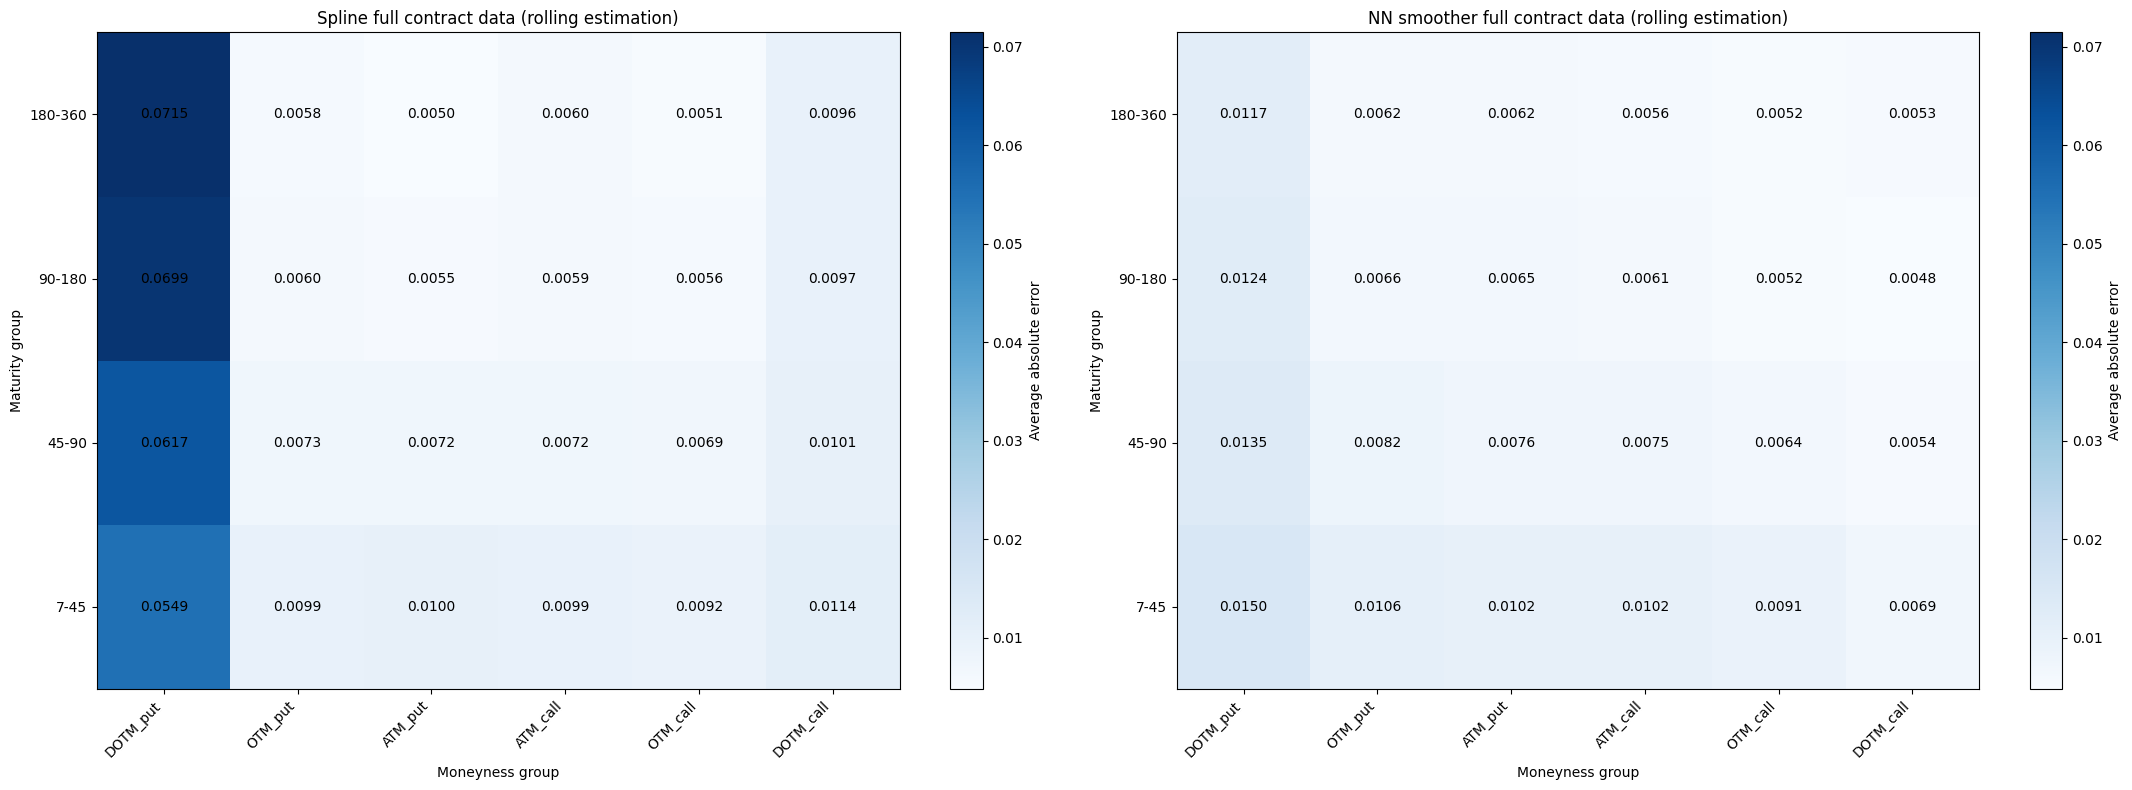

In [42]:
# Compute minimum MAE value across models
vmin_mae = min(spline_heatmap_data["abs_error"].min(), nn_heatmap_data["abs_error"].min())

# Compute maximum MAE value across models
vmax_mae = max(spline_heatmap_data["abs_error"].max(),nn_heatmap_data["abs_error"].max())

# Set plotting environment
fig, axes = plt.subplots(1, 2, figsize=(22, 8))

# Create MAE heatmap for the spline model
heatmap_table_spline_mae = make_error_heatmap(
    spline_heatmap_data,
    value_col="abs_error",
    cbar_label="Average absolute error",
    title="Spline full contract data (rolling estimation)",
    ax=axes[0],
    show=False,
    vmin=vmin_mae,
    vmax=vmax_mae)

# Create MAE heatmap for smoother
heatmap_table_nn_mae = make_error_heatmap(
    nn_heatmap_data,
    value_col="abs_error",
    cbar_label="Average absolute error",
    title="NN smoother full contract data (rolling estimation)",
    ax=axes[1],
    show=False,
    vmin=vmin_mae,
    vmax=vmax_mae)

# Plot the results
fig.tight_layout()
plt.savefig("/Users/euanbronsky/Downloads/heatmap.spline.nn.mae.new.png", bbox_inches="tight")
plt.show()

# **Pairwise Diebold-Mariano tests**

- **DM test function**

In [43]:
# Diebold-Mariano test function
def dm_test_loss(loss_model, loss_benchmark, lag=5):

    # Compute the loss differential
    loss_diff = np.asarray(loss_model) - np.asarray(loss_benchmark)

    # Length of the series, mean differential, and demean
    T = len(loss_diff)
    d_bar = np.mean(loss_diff)
    u = loss_diff - d_bar

    # Average squared deviation
    lrv = np.mean(u * u)

    # HAC standard errors
    for j in range(1, lag + 1):

        # Compute gamma and autocovariance corrections
        gamma = np.mean(u[j:] * u[:-j])
        lrv += 2 * (1 - j / (lag + 1)) * gamma

    # Compute standard error, test statistic, and p-value
    se = np.sqrt(lrv / T)
    dm_stat = d_bar / se
    p_value = 2 * (1 - norm.cdf(np.abs(dm_stat)))

    # Return the results
    return dm_stat, p_value

- **Pairwise DM tests**

In [44]:
# Pairwise Diebold-Mariano test function
def pairwise_dm_matrices(losses):

    # Extract the model names from the dictionary and store them as a list
    names = list(losses.keys())

    # Create two empty square DataFrames
    dm_mat = pd.DataFrame(index=names, columns=names, dtype=float)
    p_mat = pd.DataFrame(index=names, columns=names, dtype=float)

    # Loop to fill the pairwise DM matrix
    for i in names:
        for j in names:

            # If row and column model are the same, do not run DM test
            if i == j:
                dm_mat.loc[i, j] = np.nan
                p_mat.loc[i, j] = np.nan

            # Else extract the DM results
            else:

                # Obtain common dates
                common = losses[i].index.intersection(losses[j].index)

                # Apply DM test
                dm_stat, p_value = dm_test_loss(
                    losses[i].loc[common].to_numpy(),
                    losses[j].loc[common].to_numpy())

                # Store the DM statistic and p-value
                dm_mat.loc[i, j] = dm_stat
                p_mat.loc[i, j] = p_value

    # Return the results
    return dm_mat, p_mat, names

- **Helper function**

In [45]:
# Significance stars helper function
def significance_stars(p):
    if p < 0.01:
        return "***"
    elif p < 0.05:
        return "**"
    elif p < 0.10:
        return "*"
    else:
        return ""

- **Heatmap function**

In [46]:
# Heatmap drawing function
def add_dm_heatmap(ax, dm_mat, p_mat, names, title, cmap):

    # Find the largest absolute DM statistic in the matrix, ignore the NaN
    v = np.nanmax(np.abs(dm_mat.to_numpy(dtype=float)))
    color_norm = TwoSlopeNorm(vmin=-v, vcenter=0, vmax=v)

    # Draw the heatmap
    im = ax.imshow(dm_mat.astype(float), cmap=cmap, norm=color_norm)

    # Set x- and y-axis specifics
    ax.set_xticks(range(len(names)))
    ax.set_yticks(range(len(names)))
    ax.set_xticklabels(names, rotation=45, ha="right")
    ax.set_yticklabels(names)

    # Write text inside each heatmap cell
    for r in range(len(names)):
        for c in range(len(names)):

            # Check whether cell is missing, write a - there
            if pd.isna(dm_mat.iloc[r, c]):
                ax.text(c, r, "-", ha="center", va="center", fontsize=8)
            else:

                # Get p-value and convert it into stars
                p = p_mat.iloc[r, c]
                stars = significance_stars(p)

                # Write the DM statistic and p-value inside the cell
                ax.text(c, r, f"{dm_mat.iloc[r, c]:.2f}{stars}\n({p:.3f})", ha="center", va="center", fontsize=8)

    # Set title
    ax.set_title(title)

    # Return result
    return im

- **Daily losses**

In [47]:
# Daily loss function for rolling full-contract OOS data
def daily_loss_from_oos(x, loss_type, group=None):

    # Copy data
    df = x.copy()

    # Optionally filter region
    if group is not None:
        df = df[df["moneyness_group"] == group].copy()

    # Select loss column
    if loss_type == "mse":
        loss_col = "squared_error"
    elif loss_type == "mae":
        loss_col = "abs_error"

    # Average within each day first
    daily_loss = (
        df
        .groupby("quote_date")[loss_col]
        .mean()
        .sort_index())

    # Return daily loss
    return daily_loss

- **Align losses**

In [48]:
# Align loss series
def align_losses(losses):

    # Concatenate and drop missing dates
    return pd.concat(losses, axis=1).dropna()

- **Align the losses**

In [49]:
# Full-contract aggregate MSE losses
loss_df_full_mse = align_losses({
    "VAR": daily_loss_from_oos(x_oos_ss_var_full, "mse"),
    "OU": daily_loss_from_oos(x_oos_ou_full, "mse"),
    "Spline": daily_loss_from_oos(x_oos_spline_full, "mse"),
    "NN": daily_loss_from_oos(x_oos_nn_full, "mse")})

# Full-contract aggregate MAE losses
loss_df_full_mae = align_losses({
    "VAR": daily_loss_from_oos(x_oos_ss_var_full, "mae"),
    "OU": daily_loss_from_oos(x_oos_ou_full, "mae"),
    "Spline": daily_loss_from_oos(x_oos_spline_full, "mae"),
    "NN": daily_loss_from_oos(x_oos_nn_full, "mae")})

- **Aggregate results**

In [50]:
# Full-contract data MSE pairwise DM tests
dm_mse_full, p_mse_full, names_full = pairwise_dm_matrices({
    "VAR": loss_df_full_mse["VAR"],
    "OU": loss_df_full_mse["OU"],
    "Spline": loss_df_full_mse["Spline"],
    "NN": loss_df_full_mse["NN"]})

# Full-contract data MAE pairwise DM tests
dm_mae_full, p_mae_full, _ = pairwise_dm_matrices({
    "VAR": loss_df_full_mae["VAR"],
    "OU": loss_df_full_mae["OU"],
    "Spline": loss_df_full_mae["Spline"],
    "NN": loss_df_full_mae["NN"]})

- **Plot heatmap**

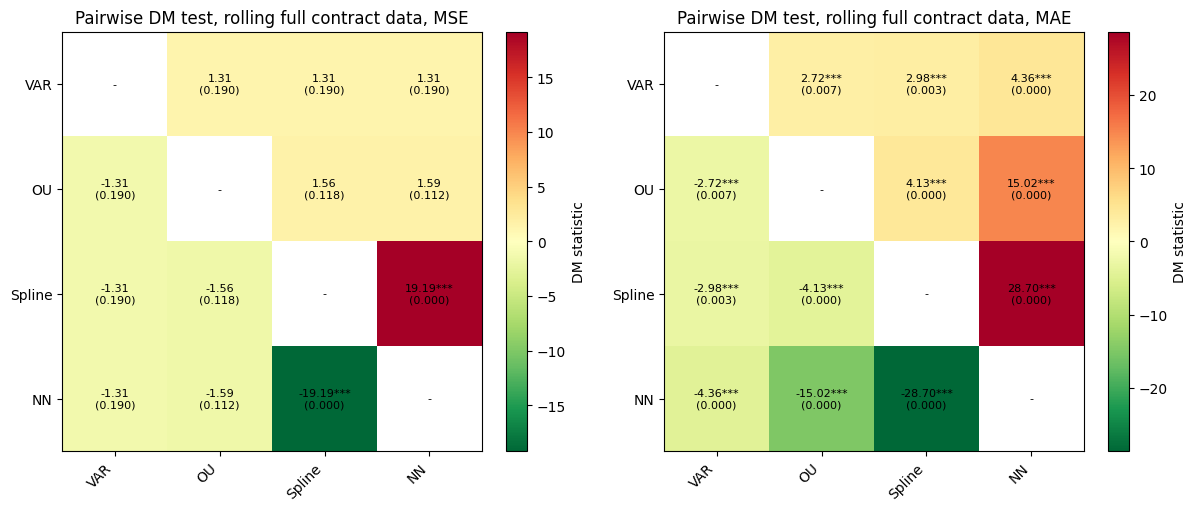

In [51]:
# Specify the colormap
cmap = plt.colormaps["RdYlGn_r"].copy()
cmap.set_bad("white")

# Set plotting environment
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

# Draw the heatmap for MSE and store result
im_mse = add_dm_heatmap(
    axes[0],
    dm_mse_full,
    p_mse_full,
    names_full,
    "Pairwise DM test, rolling full contract data, MSE",
    cmap)

# Draw the heatmap for MAE and store result
im_mae = add_dm_heatmap(
    axes[1],
    dm_mae_full,
    p_mae_full,
    names_full,
    "Pairwise DM test, rolling full contract data, MAE",
    cmap)

# Set the colorbar
fig.colorbar(im_mse, ax=axes[0], label="DM statistic")
fig.colorbar(im_mae, ax=axes[1], label="DM statistic")

# Plot the results
plt.savefig("/Users/euanbronsky/Downloads/heatmap.rolling.full.png", bbox_inches="tight")
plt.show()

- **Align losses**

In [52]:
# Specify region
group = "DOTM_put"

# Full-contract region-specific MSE losses
loss_region_full_mse = align_losses({
    "VAR": daily_loss_from_oos(x_oos_ss_var_full, "mse", group=group),
    "OU": daily_loss_from_oos(x_oos_ou_full, "mse", group=group),
    "Spline": daily_loss_from_oos(x_oos_spline_full, "mse", group=group),
    "NN": daily_loss_from_oos(x_oos_nn_full, "mse", group=group)})

# Full-contract region-specific MAE losses
loss_region_full_mae = align_losses({
    "VAR": daily_loss_from_oos(x_oos_ss_var_full, "mae", group=group),
    "OU": daily_loss_from_oos(x_oos_ou_full, "mae", group=group),
    "Spline": daily_loss_from_oos(x_oos_spline_full, "mae", group=group),
    "NN": daily_loss_from_oos(x_oos_nn_full, "mae", group=group)})

- **Region-specific results**

In [53]:
# Full-contract region-specific MSE pairwise DM tests
dm_mse_full_region, p_mse_full_region, names_full_region = pairwise_dm_matrices({
    "VAR": loss_region_full_mse["VAR"],
    "OU": loss_region_full_mse["OU"],
    "Spline": loss_region_full_mse["Spline"],
    "NN": loss_region_full_mse["NN"]})

# Full-contract region-specific MAE pairwise DM tests
dm_mae_full_region, p_mae_full_region, _ = pairwise_dm_matrices({
    "VAR": loss_region_full_mae["VAR"],
    "OU": loss_region_full_mae["OU"],
    "Spline": loss_region_full_mae["Spline"],
    "NN": loss_region_full_mae["NN"]})

- **Plot heatmap**

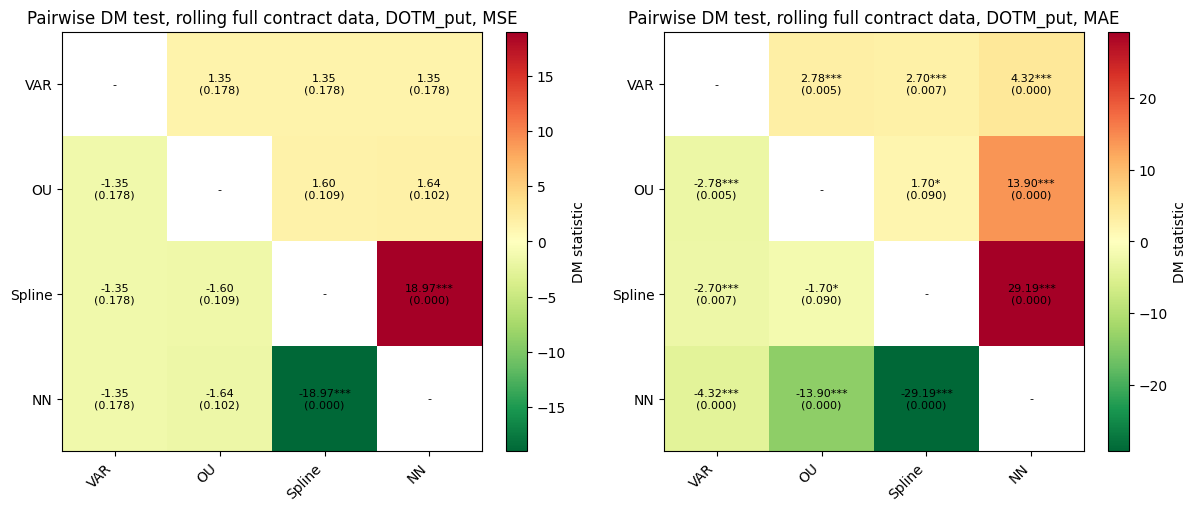

In [54]:
# Specify the colormap
cmap = plt.colormaps["RdYlGn_r"].copy()
cmap.set_bad("white")

# Set plotting environment
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

# Draw the heatmap for MSE and store result
im_mse = add_dm_heatmap(
    axes[0],
    dm_mse_full_region,
    p_mse_full_region,
    names_full_region,
    f"Pairwise DM test, rolling full contract data, {group}, MSE",
    cmap)

# Draw the heatmap for MAE and store result
im_mae = add_dm_heatmap(
    axes[1],
    dm_mae_full_region,
    p_mae_full_region,
    names_full_region,
    f"Pairwise DM test, rolling full contract data, {group}, MAE",
    cmap)

# Set the colorbar
fig.colorbar(im_mse, ax=axes[0], label="DM statistic")
fig.colorbar(im_mae, ax=axes[1], label="DM statistic")

# Plot the results
plt.savefig("/Users/euanbronsky/Downloads/heatmap.rolling.full.region.png", bbox_inches="tight")
plt.show()

# **Tests relative to the smoother only**

- **COVID period and excluding 2023**

In [55]:
# DM tests relative to Smoother only
def dm_against_smoother(losses, benchmark="Smoother"):

    # Create empty list for results
    rows = []

    # Loop over all models
    for model in losses.keys():

        # Skip the benchmark itself
        if model == benchmark:
            continue

        # Obtain common dates between model and Smoother
        common = losses[model].index.intersection(losses[benchmark].index)

        # Compute the DM statistic and p-value
        dm_stat, p_value = dm_test_loss(
            losses[model].loc[common].to_numpy(),
            losses[benchmark].loc[common].to_numpy())

        # Store the results
        rows.append({
            "model": model,
            "benchmark": benchmark,
            "dm_stat": dm_stat,
            "p_value": p_value,})

    # Return the results as DataFrame
    return pd.DataFrame(rows)

In [56]:
# Create period loss function
def get_period_losses(period, group=None):

    # Store all model dataframes
    data_dict = {
        "VAR": x_oos_ss_var_full.copy(),
        "OU": x_oos_ou_full.copy(),
        "Spline": x_oos_spline_full.copy(),
        "Smoother": x_oos_nn_full.copy()}

    # Loop over all models
    for name in data_dict.keys():

        # Select COVID period
        if period == "covid":

            # Keep COVID dates
            data_dict[name] = data_dict[name][
                data_dict[name]["quote_date"].between("2020-01-01", "2022-12-31")
            ].copy()

        # Select excluding 2023 period
        elif period == "excl_2023":

            # Remove 2023 dates
            data_dict[name] = data_dict[name][
                data_dict[name]["quote_date"].dt.year != 2023
                ].copy()

    # Construct MSE daily losses
    losses_mse = {
        name: daily_loss_from_oos(data_dict[name], "mse", group=group)
        for name in data_dict.keys()}

    # Construct MAE daily losses
    losses_mae = {
        name: daily_loss_from_oos(data_dict[name], "mae", group=group)
        for name in data_dict.keys()}

    # Return MSE and MAE losses
    return losses_mse, losses_mae

- **Print COVID aggregate results**

In [57]:
# Get COVID all-region losses
losses_covid_mse, losses_covid_mae = get_period_losses(
    period="covid",
    group=None)

# Compute MSE DM tests against Smoother
dm_covid_mse_vs_smoother = dm_against_smoother(losses_covid_mse)

# Compute MAE DM tests against Smoother
dm_covid_mae_vs_smoother = dm_against_smoother(losses_covid_mae)

# Print MSE results
print("COVID period, all regions, MSE")
print(dm_covid_mse_vs_smoother)

# Print MAE results
print("COVID period, all regions, MAE")
print(dm_covid_mae_vs_smoother)

COVID period, all regions, MSE
    model benchmark    dm_stat   p_value
0     VAR  Smoother  15.015760  0.000000
1      OU  Smoother   4.827934  0.000001
2  Spline  Smoother   9.746496  0.000000
COVID period, all regions, MAE
    model benchmark    dm_stat  p_value
0     VAR  Smoother  21.750860      0.0
1      OU  Smoother  16.048703      0.0
2  Spline  Smoother  10.614732      0.0


- **Print COVID region-specific results**

In [58]:
# Get COVID DOTM put losses
losses_covid_dotm_mse, losses_covid_dotm_mae = get_period_losses(
    period="covid",
    group="DOTM_put")

# Compute MSE DM tests against Smoother
dm_covid_dotm_mse_vs_smoother = dm_against_smoother(losses_covid_dotm_mse)

# Compute MAE DM tests against Smoother
dm_covid_dotm_mae_vs_smoother = dm_against_smoother(losses_covid_dotm_mae)

# Print MSE results
print("COVID period, DOTM put, MSE")
print(dm_covid_dotm_mse_vs_smoother)

# Print MAE results
print("COVID period, DOTM put, MAE")
print(dm_covid_dotm_mae_vs_smoother)

COVID period, DOTM put, MSE
    model benchmark    dm_stat       p_value
0     VAR  Smoother  14.459727  0.000000e+00
1      OU  Smoother   4.993098  5.941840e-07
2  Spline  Smoother  10.178787  0.000000e+00
COVID period, DOTM put, MAE
    model benchmark    dm_stat  p_value
0     VAR  Smoother  18.834781      0.0
1      OU  Smoother  14.528183      0.0
2  Spline  Smoother  11.208301      0.0


- **Print excluding 2023 aggregate results**

In [59]:
# Get excluding 2023 all-region losses
losses_excl_2023_mse, losses_excl_2023_mae = get_period_losses(
    period="excl_2023",
    group=None)

# Compute MSE DM tests against Smoother
dm_excl_2023_mse_vs_smoother = dm_against_smoother(losses_excl_2023_mse)

# Compute MAE DM tests against Smoother
dm_excl_2023_mae_vs_smoother = dm_against_smoother(losses_excl_2023_mae)

# Print MSE results
print("Excluding 2023, all regions, MSE")
print(dm_excl_2023_mse_vs_smoother)

# Print MAE results
print("Excluding 2023, all regions, MAE")
print(dm_excl_2023_mae_vs_smoother)

Excluding 2023, all regions, MSE
    model benchmark    dm_stat       p_value
0     VAR  Smoother  15.720246  0.000000e+00
1      OU  Smoother   5.932424  2.984954e-09
2  Spline  Smoother  18.484013  0.000000e+00
Excluding 2023, all regions, MAE
    model benchmark    dm_stat  p_value
0     VAR  Smoother  31.095950      0.0
1      OU  Smoother  22.665044      0.0
2  Spline  Smoother  27.827342      0.0


- **Print excluding 2023 region-specific results**

In [60]:
# Get excluding 2023 DOTM put losses
losses_excl_2023_dotm_mse, losses_excl_2023_dotm_mae = get_period_losses(
    period="excl_2023",
    group="DOTM_put")

# Compute MSE DM tests against Smoother
dm_excl_2023_dotm_mse_vs_smoother = dm_against_smoother(losses_excl_2023_dotm_mse)

# Compute MAE DM tests against Smoother
dm_excl_2023_dotm_mae_vs_smoother = dm_against_smoother(losses_excl_2023_dotm_mae)

# Print MSE results
print("Excluding 2023, DOTM put, MSE")
print(dm_excl_2023_dotm_mse_vs_smoother)

# Print MAE results
print("Excluding 2023, DOTM put, MAE")
print(dm_excl_2023_dotm_mae_vs_smoother)

Excluding 2023, DOTM put, MSE
    model benchmark    dm_stat       p_value
0     VAR  Smoother  15.106263  0.000000e+00
1      OU  Smoother   6.051034  1.439193e-09
2  Spline  Smoother  18.145101  0.000000e+00
Excluding 2023, DOTM put, MAE
    model benchmark    dm_stat  p_value
0     VAR  Smoother  27.091747      0.0
1      OU  Smoother  19.886984      0.0
2  Spline  Smoother  27.722132      0.0
